# CMU20 LLM Energy Comparison

This notebook loads the CMU20 energy test results of four LLM backends.

Figure saved: figure2_combined_panelab.png


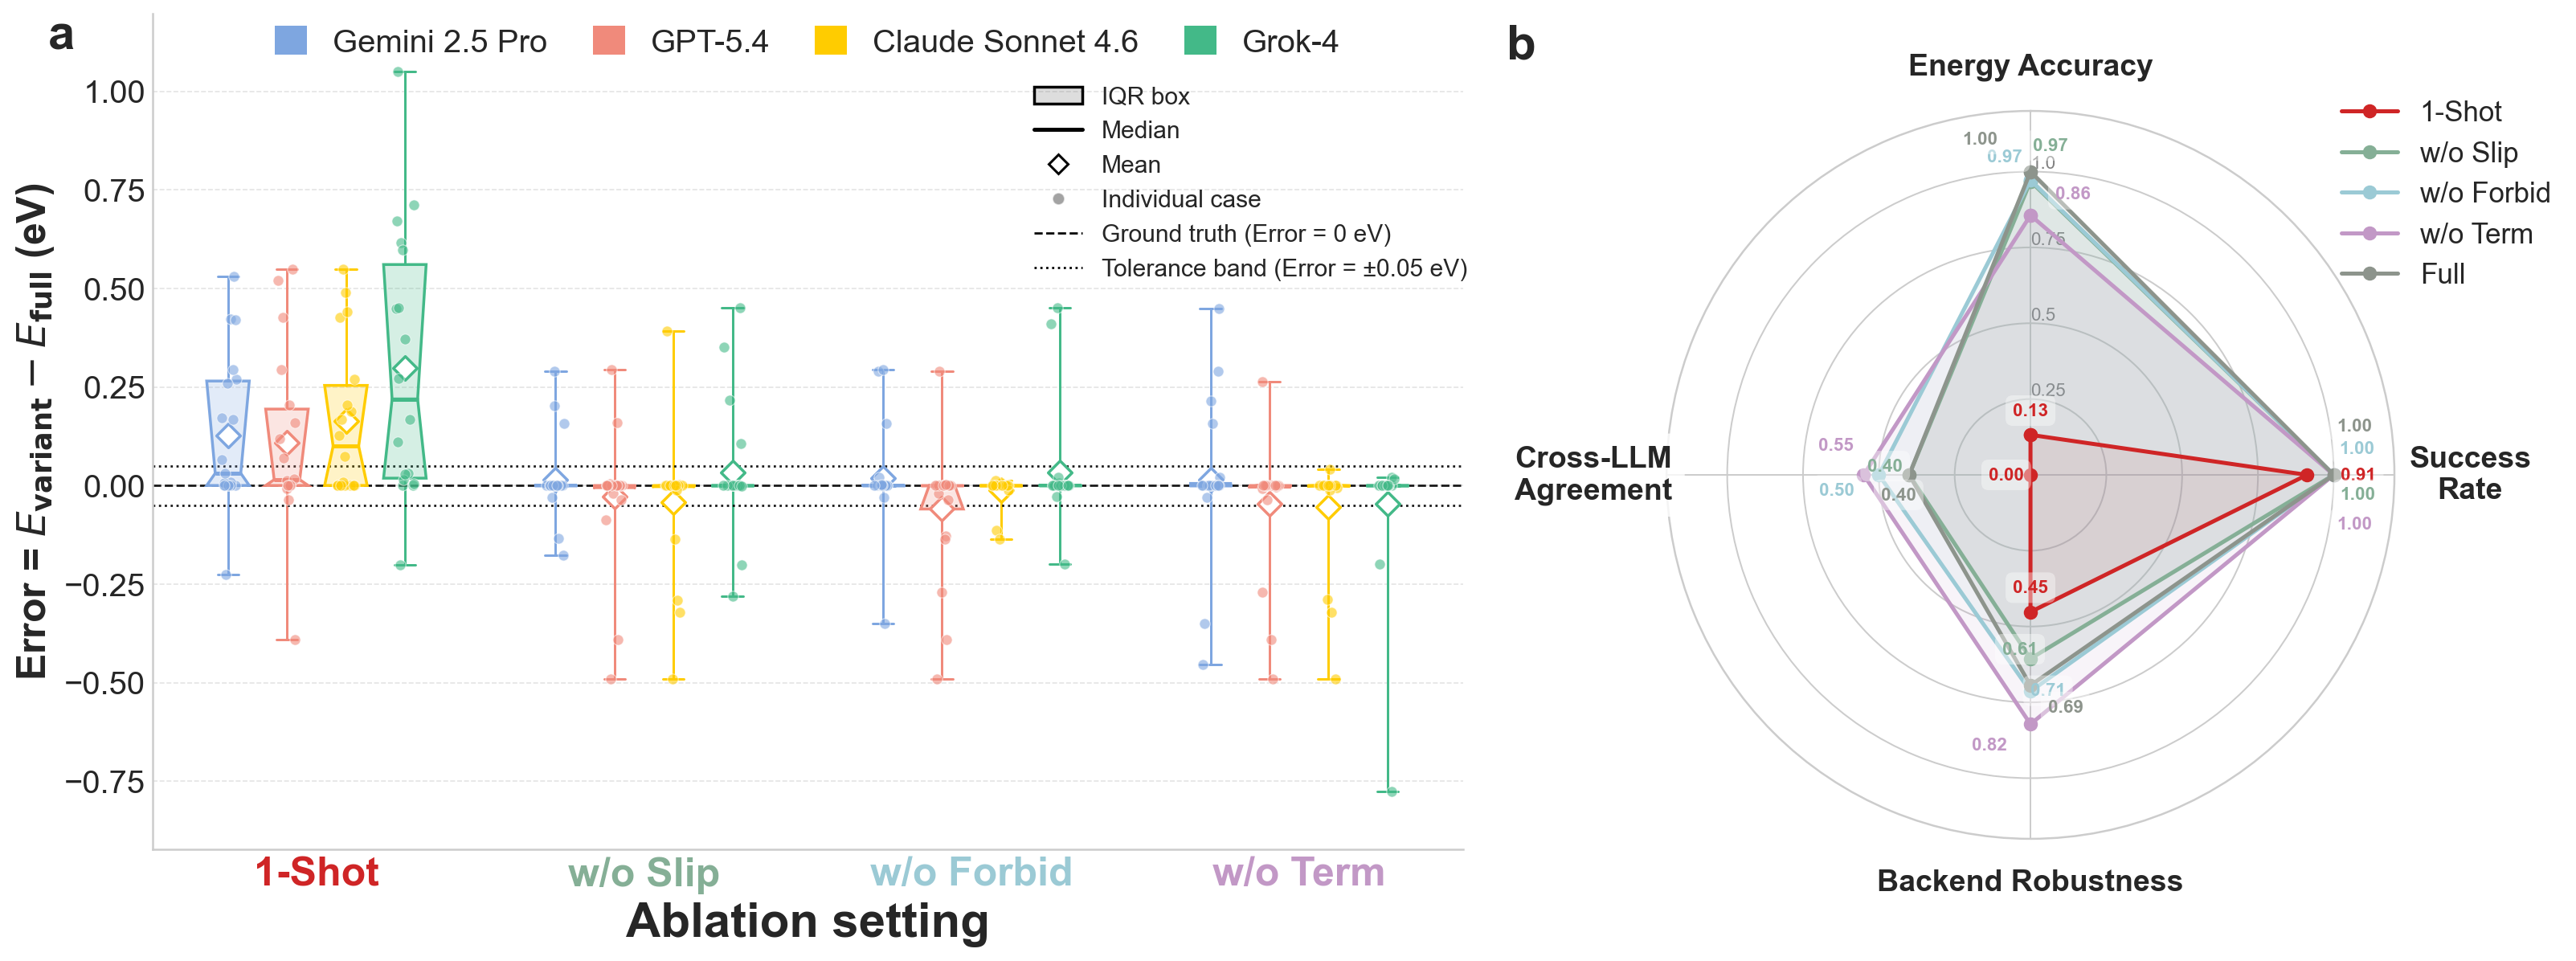

In [3]:
#!/usr/bin/env python
"""
Generate Figure 2 with two panels:
Panel a (left): trapezoid plot (ablation performance across LLMs)
Panel b (right): radar chart (variant comparison)
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

data_path = Path("../../results/basic_experiments/cmu20/summaries/ablation_4backend.csv")
df_ablation = pd.read_csv(data_path)
df_ablation["case_id"] = df_ablation["case_id"].astype(str).str.strip().str.zfill(2)
df_ablation["best_energy_eV"] = pd.to_numeric(df_ablation["best_energy_eV"], errors="coerce")
df_ablation["success"] = df_ablation["success"].astype(str).str.upper().eq("TRUE")
df_ablation.loc[~df_ablation["success"], "best_energy_eV"] = np.nan

variant_map = {
    "full": "Full",
    "one_shot": "1-Shot",
    "no_slip": "-Slip",
    "no_forbid": "-Forbid",
    "no_termination": "-Term",
}
plot_order = ["1-Shot", "-Slip", "-Forbid", "-Term"]
backend_to_model = {
    "gemini": "Gemini 2.5 Pro",
    "gpt": "GPT-5.4",
    "claude": "Claude Sonnet 4.6",
    "grok": "Grok-4",
}

# ================================================================
# PANEL A: Trapezoid plot
# ================================================================
model_config = {
    "Gemini 2.5 Pro": {"color": "#7EA6E0"},
    "GPT-5.4":        {"color": "#F08A7B"},
    "Claude Sonnet 4.6": {"color": "#FFCC00"},
    "Grok-4":         {"color": "#43B988"},
}

frames = {}
for backend_key, model_name in backend_to_model.items():
    df_backend = df_ablation[df_ablation["backend_key"] == backend_key].copy()
    df_pivot = df_backend.pivot(index="case_id", columns="variant", values="best_energy_eV")
    df_pivot = df_pivot.rename(columns=variant_map)
    for col in ["Full"] + plot_order:
        if col not in df_pivot.columns:
            df_pivot[col] = np.nan
    df_pivot = df_pivot[["Full"] + plot_order]
    df_pivot = df_pivot.reset_index().rename(columns={"case_id": "Case"})
    for scenario in plot_order:
        df_pivot[scenario] = df_pivot[scenario] - df_pivot["Full"]
    df_pivot = df_pivot.sort_values("Case", key=lambda s: s.astype(int)).reset_index(drop=True)
    frames[model_name] = df_pivot

all_values = []
for model_name in model_config:
    for scenario in plot_order:
        all_values.extend(frames[model_name][scenario].dropna().to_numpy(dtype=float).tolist())
y_min = float(np.nanmin(all_values))
y_max = float(np.nanmax(all_values))
y_pad = 0.08 * max(1e-6, y_max - y_min)
ylim = (y_min - y_pad, y_max + y_pad)

# Create 1x2 figure
fig = plt.figure(figsize=(20, 7.5), dpi=180)
gs = fig.add_gridspec(1, 2, width_ratios=[1.8, 1.0])
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1], projection='polar')

# Shift Panel B vertically (positive -> up, negative -> down). Adjust as needed.
panel_b_shift = -0.04  # try -0.06 to move down by ~6% of figure height
pos_b = ax_b.get_position()
ax_b.set_position([pos_b.x0, pos_b.y0 + panel_b_shift, pos_b.width, pos_b.height])

# ---- Panel a: trapezoid plot ----
rng = np.random.default_rng(2026)
model_names = list(model_config.keys())
n_models = len(model_names)
x_base = np.arange(1, len(plot_order) + 1)
offset_span = 0.54
offsets = np.linspace(-offset_span / 2.0, offset_span / 2.0, n_models)
box_half_width = 0.065
neck_half_width = 0.6 * box_half_width

for offset, model_name in zip(offsets, model_names):
    cfg = model_config[model_name]
    color = cfg["color"]
    df = frames[model_name]
    values_by_setting = [df[scenario].dropna().to_numpy(dtype=float) for scenario in plot_order]
    x_positions = x_base + offset

    ax_a.boxplot(
        values_by_setting, positions=x_positions, widths=2.0 * box_half_width,
        whis=(0, 100), patch_artist=True, showfliers=False,
        boxprops={"facecolor": "none", "edgecolor": "none", "linewidth": 0.0},
        whiskerprops={"color": color, "linewidth": 1.2},
        capprops={"color": color, "linewidth": 1.2},
        medianprops={"color": color, "linewidth": 0.0},
    )

    for pos, values in zip(x_positions, values_by_setting):
        if len(values) == 0:
            continue
        q1 = float(np.nanpercentile(values, 25))
        q3 = float(np.nanpercentile(values, 75))
        median_val = float(np.nanmedian(values))
        mean_val = float(np.nanmean(values))

        lower = Polygon([(pos - box_half_width, q1), (pos + box_half_width, q1),
                         (pos + neck_half_width, median_val), (pos - neck_half_width, median_val)],
                        closed=True, facecolor=to_rgba(color, 0.22), edgecolor=color, linewidth=1.4, zorder=3.1)
        upper = Polygon([(pos - neck_half_width, median_val), (pos + neck_half_width, median_val),
                         (pos + box_half_width, q3), (pos - box_half_width, q3)],
                        closed=True, facecolor=to_rgba(color, 0.22), edgecolor=color, linewidth=1.4, zorder=3.1)
        ax_a.add_patch(lower)
        ax_a.add_patch(upper)
        ax_a.hlines(median_val, pos - neck_half_width, pos + neck_half_width, color=color, linewidth=2.0, zorder=3.8)
        ax_a.scatter(pos, mean_val, marker="D", s=70, facecolor="white", edgecolor=color, linewidth=1.4, zorder=4)
        jitter = rng.uniform(-0.028, 0.028, size=len(values))
        ax_a.scatter(np.full_like(values, pos, dtype=float) + jitter, values,
                     s=28, color=color, edgecolors="white", linewidths=0.45, alpha=0.6, zorder=5)

ax_a.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.9, zorder=2)
ax_a.axhline(0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)
ax_a.axhline(-0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)

llm_handles = [Patch(facecolor=model_config[name]["color"], edgecolor="none", label=name)
               for name in model_names]
legend_llm = ax_a.legend(handles=llm_handles, loc="upper center", bbox_to_anchor=(0.5, 1.02),
                          ncol=n_models, frameon=False, handlelength=1.0, handleheight=1.0,
                          columnspacing=1.4, fontsize=16)
ax_a.add_artist(legend_llm)

style_handles = [
    Patch(facecolor=to_rgba("#666666", 0.22), edgecolor="black", linewidth=1.4, label="IQR box"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Median"),
    Line2D([0], [0], marker="D", linestyle="None", markersize=7,
             markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.2, label="Mean"),
    Line2D([0], [0], marker="o", linestyle="None", markersize=6,
             markerfacecolor="#666666", markeredgecolor="white", markeredgewidth=0.7,
             alpha=0.6, label="Individual case"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.1, label="Ground truth (Error = 0 eV)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.1, label="Tolerance band (Error = ±0.05 eV)"),
]
ax_a.legend(handles=style_handles, bbox_to_anchor=(1.02, 0.94), loc='upper right', fontsize=12, frameon=False)
ax_a.set_xlim(0.5, len(plot_order) + 0.5)
ax_a.set_xticks(x_base)
ax_a.set_xticklabels(["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term"], fontsize=20)
# Color x-axis labels to match Panel B legend
colors_xaxis = ['#CF2526', '#85AF96', '#9BCAD5', '#C298C6']  # 1-Shot, w/o Slip, w/o Forbid, w/o Term
for tick, color in zip(ax_a.get_xticklabels(), colors_xaxis):
    tick.set_color(color)
    tick.set_fontweight("bold")

ax_a.set_ylim(ylim)
ax_a.set_xlabel("Ablation setting", fontsize=24, fontweight='bold')
ax_a.set_ylabel(r"Error = $E_{\mathbf{variant}} - E_{\mathbf{full}}$ (eV)", fontsize=20, fontweight='bold')
ax_a.tick_params(axis="y", labelsize=16)
ax_a.grid(True, axis="y", linestyle="--", linewidth=0.65, alpha=0.55)
ax_a.grid(False, axis="x")

# Panel label "a"
ax_a.text(-0.08, 1, "a", transform=ax_a.transAxes,
           fontsize=24, fontweight='bold', va='top', ha='left')
# ================================================================
# PANEL B: Radar chart
# ================================================================
table1_data = {
    'Variant': ['1-Shot', 'w/o Slip', 'w/o Forbid', 'w/o Term', 'Full'],
    'Mean_dE_vs_full_eV': [0.217, -0.008, -0.007, -0.036, 0.000],
    'Success_rate': [91.2, 100.0, 100.0, 100.0, 100.0]
}
table3_data = {
    'Variant': ['1-Shot', 'w/o Slip', 'w/o Forbid', 'w/o Term', 'Full'],
    'Mean_4backend_range_eV': [0.274, 0.197, 0.143, 0.089, 0.153],
    'Agreement_rate': [0.000000, 0.400000, 0.500000, 0.550000, 0.400000]
}
df1 = pd.DataFrame(table1_data)
df3 = pd.DataFrame(table3_data)
df_merged = pd.merge(df1, df3, on='Variant')
order = ['1-Shot', 'w/o Slip', 'w/o Forbid', 'w/o Term', 'Full']
df_radar = df_merged.set_index('Variant').reindex(order).reset_index()

df_radar['Norm_dE'] = 1 - (np.abs(df_radar['Mean_dE_vs_full_eV']) / 0.25)
df_radar['Norm_success'] = df_radar['Success_rate'] / 100
df_radar['Norm_robustness'] = 1 - (df_radar['Mean_4backend_range_eV'] / 0.5)
df_radar['Norm_agreement'] = df_radar['Agreement_rate']
for col in ['Norm_dE', 'Norm_success', 'Norm_robustness', 'Norm_agreement']:
    df_radar[col] = df_radar[col].clip(0, 1)

colors_radar = ['#CF2526', '#85AF96', '#9BCAD5', '#C298C6', '#8D948C']
categories = ['Energy Accuracy', 'Success\nRate', 'Backend Robustness', 'Cross-LLM\nAgreement']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_b.set_theta_offset(np.pi / 2) 
ax_b.set_theta_direction(-1)
ax_b.set_xticks(angles[:-1])
ax_b.set_xticklabels([])  # Clear auto labels; place manually below
# Manually place category labels with custom radial offsets
# 'Energy Accuracy' (top, idx 0) & 'Backend Robustness' (bottom, idx 2): CLOSER (r=1.22)
# 'Success Rate' (left, idx 1) & 'Cross-LLM Agreement' (right, idx 3): FARTHER (r=1.40)
label_rs = [1.3, 1.45, 1.3, 1.7]
for i, (angle, label) in enumerate(zip(angles[:-1], categories)):
    r = label_rs[i]
    if i == 0:  # top
        va, ha = 'bottom', 'center'
    elif i == 1:  # left
        va, ha = 'center', 'center'
    elif i == 2:  # bottom
        va, ha = 'top', 'center'
    else:  # right (i == 3)
        va, ha = 'center', 'left'
    ax_b.text(angle, r, label, fontsize=15, fontdict={'weight': 'bold'}, ha=ha, va=va,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='none'))
# Remove the old uniform pad (no longer needed)
# ax_b.tick_params(axis='x', pad=...)  # DISABLED – using manual placement above
ax_b.set_rlabel_position(0)
ax_b.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_b.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], color="grey", size=9)
ax_b.tick_params(axis='y', pad=12)
ax_b.set_ylim(0, 1.2)  # Increased to accommodate manual label placement (max r=1.40)

# Manual label_r offsets: [variant_idx][metric_idx]
# variant order: 1-Shot, w/o Slip, w/o Forbid, w/o Term, Full
# metric order: Norm_dE, Norm_success, Norm_robustness, Norm_agreement
label_r_offsets = [
    [0.08, 0.17, -0.08, 0.08],  # 1-Shot
    [0.12, 0.08, -0.03, 0.08],  # w/o Slip
    [0.08, 0.08, 0.00, 0.14],  # w/o Forbid
    [0.08, 0.08, 0.08, 0.1],  # w/o Term
    [0.12, 0.08, 0.08, 0.04],  # Full
]  # EDIT THESE VALUES to manually adjust each label_r (added to val)
# label_padding = 0.08  # DISABLED – using label_r_offsets instead
angle_offsets = [0, 0.06, -0.08, 0.15, -0.15]

for i, (idx, row) in enumerate(df_radar.iterrows()):
    values = df_radar.loc[idx, ['Norm_dE', 'Norm_success', 'Norm_robustness', 'Norm_agreement']].values.tolist()
    values += values[:1]
    ax_b.plot(angles, values, 'o-', linewidth=2, label=row['Variant'], color=colors_radar[i])
    ax_b.fill(angles, values, alpha=0.1, color=colors_radar[i])
    for j, (angle, val) in enumerate(zip(angles[:-1], values[:-1])):
        label_r = val + label_r_offsets[i][j]  # Manual offset per label
        text_angle = angle + angle_offsets[i]
        ax_b.text(text_angle, label_r, f'{val:.2f}',
                  ha='center', va='center',
                  fontsize=9, color=colors_radar[i], fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.4, edgecolor='none'))

ax_b.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=14, framealpha=0.9, frameon=False)

# Panel label "b"
ax_b.text(-0.22, 1.12, "b", transform=ax_b.transAxes,
           fontsize=24, fontweight='bold', va='top', ha='left')

# Save figure
fig.savefig("figure2_combined_panelab.png", dpi=300, bbox_inches="tight")
print("Figure saved: figure2_combined_panelab.png")
plt.show()